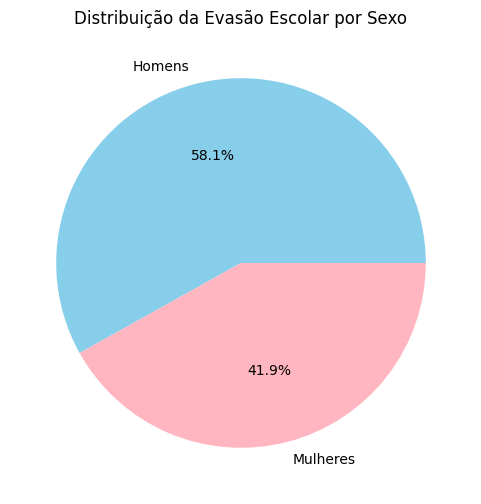

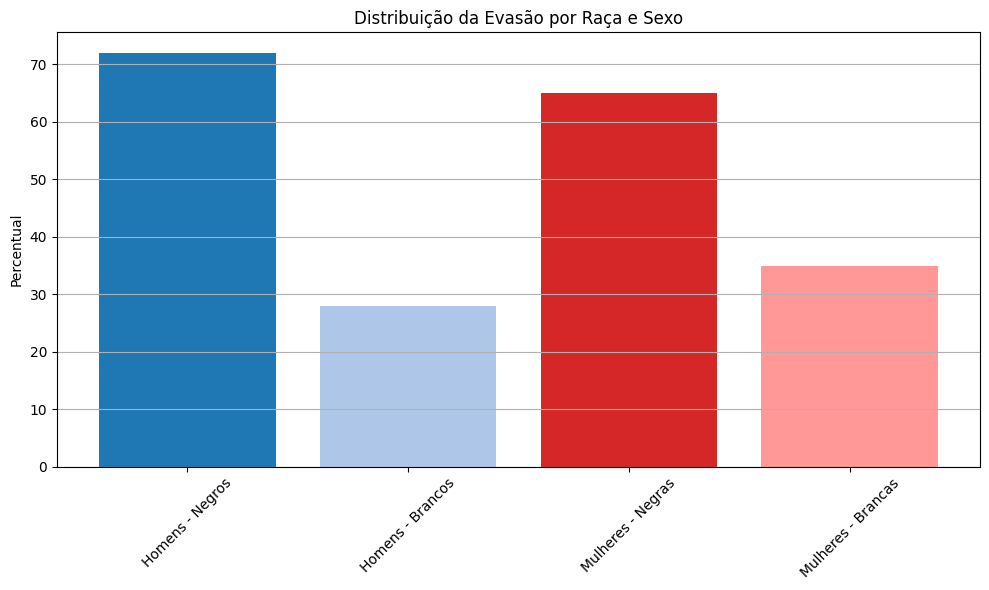

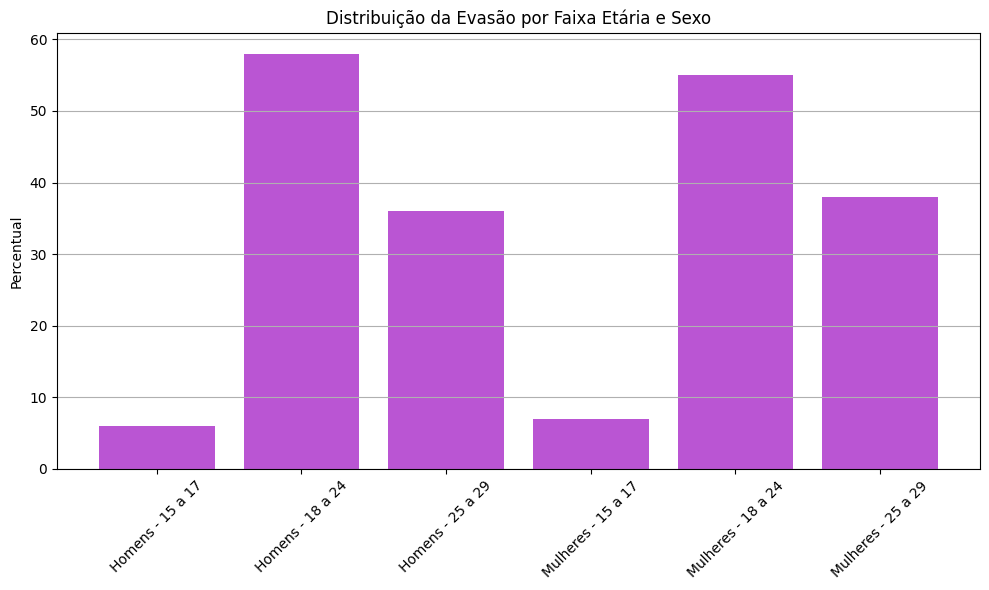

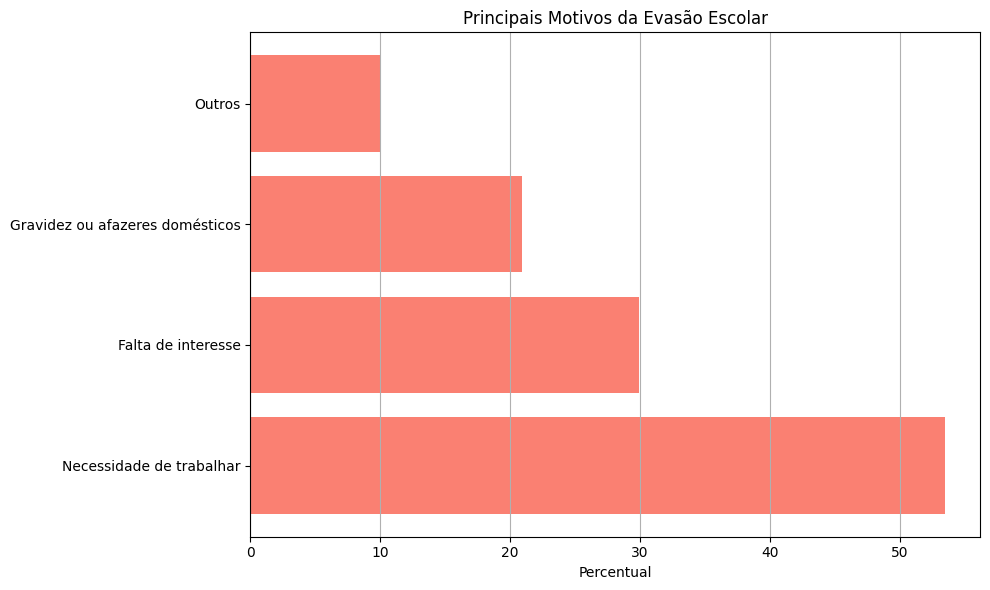

In [ ]:
# Instalar PySpark se necessário
!pip install -q pyspark


# Imports
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, DoubleType
import pandas as pd
import matplotlib.pyplot as plt
import os

# Criar diretório para salvar os gráficos
os.makedirs("graficos_evasao", exist_ok=True)

# Iniciar Spark
spark = SparkSession.builder.appName("EvasaoEscolar").getOrCreate()

# --------------------------
# 1. DISTRIBUIÇÃO POR SEXO
# --------------------------

dados_sexo = [("Homens", 58.1), ("Mulheres", 41.9)]
colunas_sexo = ["Sexo", "Percentual"]
df_sexo = spark.createDataFrame(dados_sexo, colunas_sexo)
df_sexo_pd = df_sexo.toPandas()

plt.figure(figsize=(6,6))
plt.pie(df_sexo_pd["Percentual"], labels=df_sexo_pd["Sexo"], autopct='%1.1f%%', colors=["skyblue", "lightpink"])
plt.title("Distribuição da Evasão Escolar por Sexo")
plt.savefig("graficos_evasao/evasao_por_sexo.png")
plt.savefig("graficos_evasao/evasao_por_sexo.pdf")
plt.show()

# --------------------------
# 2. RAÇA POR SEXO
# --------------------------

dados_raca = [
    ("Homens - Negros", 72),
    ("Homens - Brancos", 28),
    ("Mulheres - Negras", 65),
    ("Mulheres - Brancas", 35)
]
colunas_raca = ["Grupo", "Percentual"]
df_raca = spark.createDataFrame(dados_raca, colunas_raca)
df_raca_pd = df_raca.toPandas()

plt.figure(figsize=(10,6))
plt.bar(df_raca_pd["Grupo"], df_raca_pd["Percentual"], color=["#1f77b4", "#aec7e8", "#d62728", "#ff9896"])
plt.title("Distribuição da Evasão por Raça e Sexo")
plt.ylabel("Percentual")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("graficos_evasao/evasao_por_raca.png")
plt.savefig("graficos_evasao/evasao_por_raca.pdf")
plt.show()

# --------------------------
# 3. FAIXA ETÁRIA POR SEXO
# --------------------------

dados_idade = [
    ("Homens - 15 a 17", 6),
    ("Homens - 18 a 24", 58),
    ("Homens - 25 a 29", 36),
    ("Mulheres - 15 a 17", 7),
    ("Mulheres - 18 a 24", 55),
    ("Mulheres - 25 a 29", 38)
]
colunas_idade = ["Grupo", "Percentual"]
df_idade = spark.createDataFrame(dados_idade, colunas_idade)
df_idade_pd = df_idade.toPandas()

plt.figure(figsize=(10,6))
plt.bar(df_idade_pd["Grupo"], df_idade_pd["Percentual"], color="mediumorchid")
plt.title("Distribuição da Evasão por Faixa Etária e Sexo")
plt.ylabel("Percentual")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("graficos_evasao/evasao_por_idade.png")
plt.savefig("graficos_evasao/evasao_por_idade.pdf")
plt.show()

# --------------------------
# 4. MOTIVOS DA EVASÃO
# --------------------------

dados_motivos = [
    ("Necessidade de trabalhar", 53.5),
    ("Falta de interesse", 29.9),
    ("Gravidez ou afazeres domésticos", 20.9),
    ("Outros", 10.0) # Changed 10 to 10.0 to ensure consistency in data types
]
colunas_motivos = ["Motivo", "Percentual"]

# Define the schema explicitly
schema_motivos = StructType([
    StructField("Motivo", StringType(), True),
    StructField("Percentual", DoubleType(), True)
])

df_motivos = spark.createDataFrame(dados_motivos, schema=schema_motivos)
df_motivos_pd = df_motivos.toPandas()

plt.figure(figsize=(10,6))
plt.barh(df_motivos_pd["Motivo"], df_motivos_pd["Percentual"], color="salmon")
plt.title("Principais Motivos da Evasão Escolar")
plt.xlabel("Percentual")
plt.grid(axis="x")
plt.tight_layout()
plt.savefig("graficos_evasao/motivos_evasao.png")
plt.savefig("graficos_evasao/motivos_evasao.pdf")
plt.show()